## Department of Electronics and Telecommunications Engineering
## EN 3160
## Intensity Transformations and Neighborhood Filtering

#### Name: K. D. Manatunga
#### Index Number: 230395T

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

#### Question 01

In [2]:
im1 = cv.imread("Images/emma.jpg",cv.IMREAD_GRAYSCALE)

In [3]:
breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
], dtype=np.float32)

In [4]:
def intensity_transform(im, bp):
    x = im.astype(np.float32)
    y = np.zeros_like(x)

    for i in range(0, len(bp) - 1, 2):
        x1, y1 = bp[i]
        x2, y2 = bp[i + 1]

        if i == len(bp) - 2:
            mask = (x >= x1) & (x <= x2)
        else:
            mask = (x >= x1) & (x < x2)

        y[mask] = y1 + (y2 - y1) * (x[mask] - x1) / (x2 - x1)

    return np.clip(y, 0, 255).astype(np.uint8)

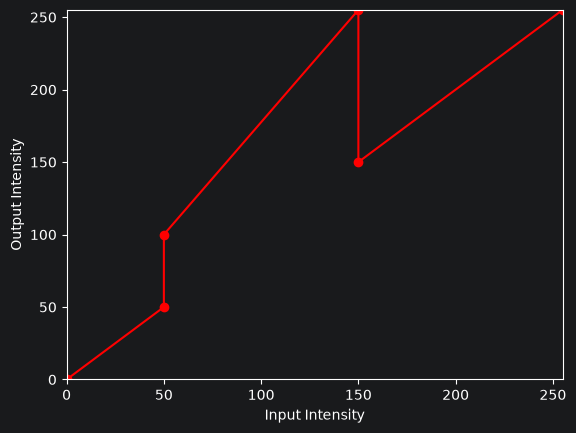

In [5]:
r1 = intensity_transform(im1, breakpoints)

plt.plot(breakpoints[:, 0], breakpoints[:, 1], marker='o', color='red')

plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.show()

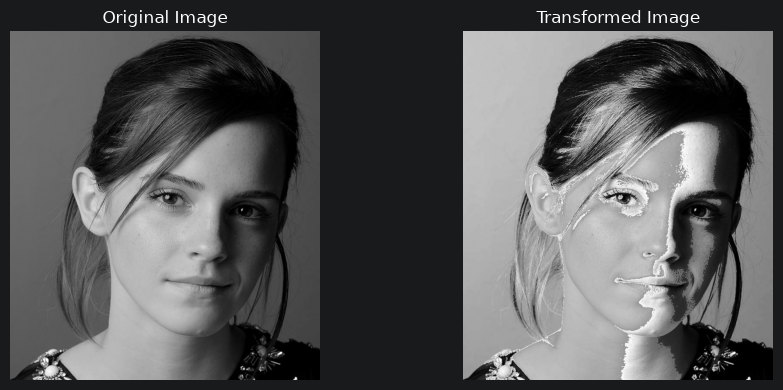

In [6]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im1, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(r1, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

##### Experimenting Using different breakpoints.

In [7]:
def intensity_transform2(im, breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    result = np.interp(im, x, y)

    return np.clip(result, 0, 255).astype(np.uint8)


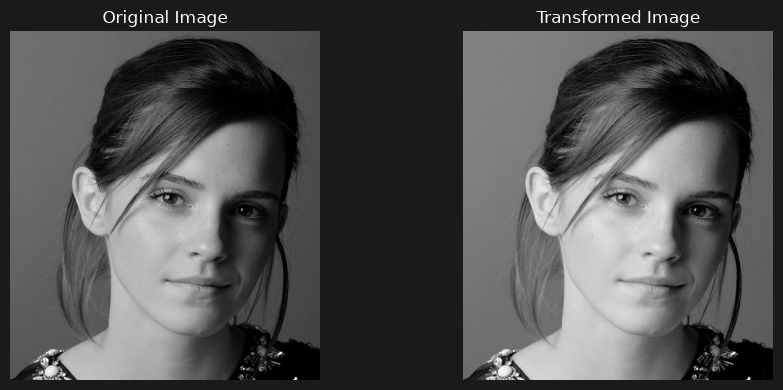

In [8]:
breakpoints2 = np.array([
    [0, 0],
    [50, 80],
    [100, 120],
    [200, 220],
    [255, 255]
], dtype=np.float32)

r2 = intensity_transform2(im1, breakpoints2)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im1, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(r2, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()


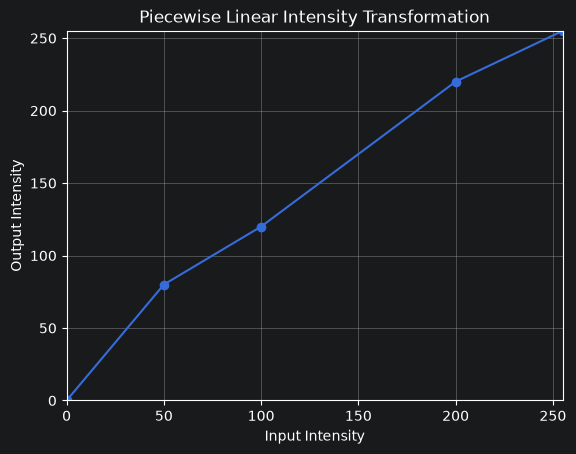

In [9]:
plt.plot(breakpoints2[:, 0], breakpoints2[:, 1], marker="o")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()
plt.title("Piecewise Linear Intensity Transformation")
plt.show()

The breakpoints were adjusted to improve the visual appearance of the image. This transformation expands darker intensity values, making shadow and mid tone details more visible while preserving the high intensity range without clipping excessively. So this transformation improves the contrast while maintaining the natural appearance.

#### Question 2

In [10]:
brain = cv.imread("Images/Fig2.jpeg", cv.IMREAD_GRAYSCALE)
#
# plt.imshow(brain, cmap="gray")
# plt.axis("off")
# plt.show()

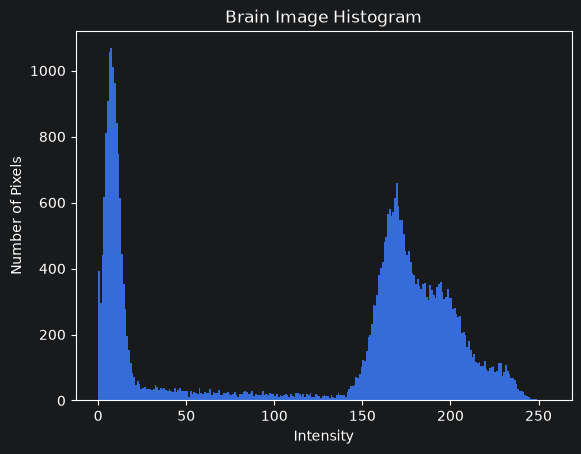

In [11]:
plt.hist(brain.ravel(), bins=256, range=(0, 256))

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Brain Image Histogram")

plt.show()

In [12]:
white_bp = np.array([
    [0, 0],
    [130, 20],
    [145, 50],
    [175, 190],
    [205, 225],
    [255, 255]
], dtype=np.float32)

gray_bp = np.array([
    [0, 0],
    [155, 20],
    [175, 50],
    [210, 200],
    [235, 235],
    [255, 255]
], dtype=np.float32)

In [13]:
white_result = intensity_transform(brain, white_bp)
gray_result = intensity_transform(brain, gray_bp)

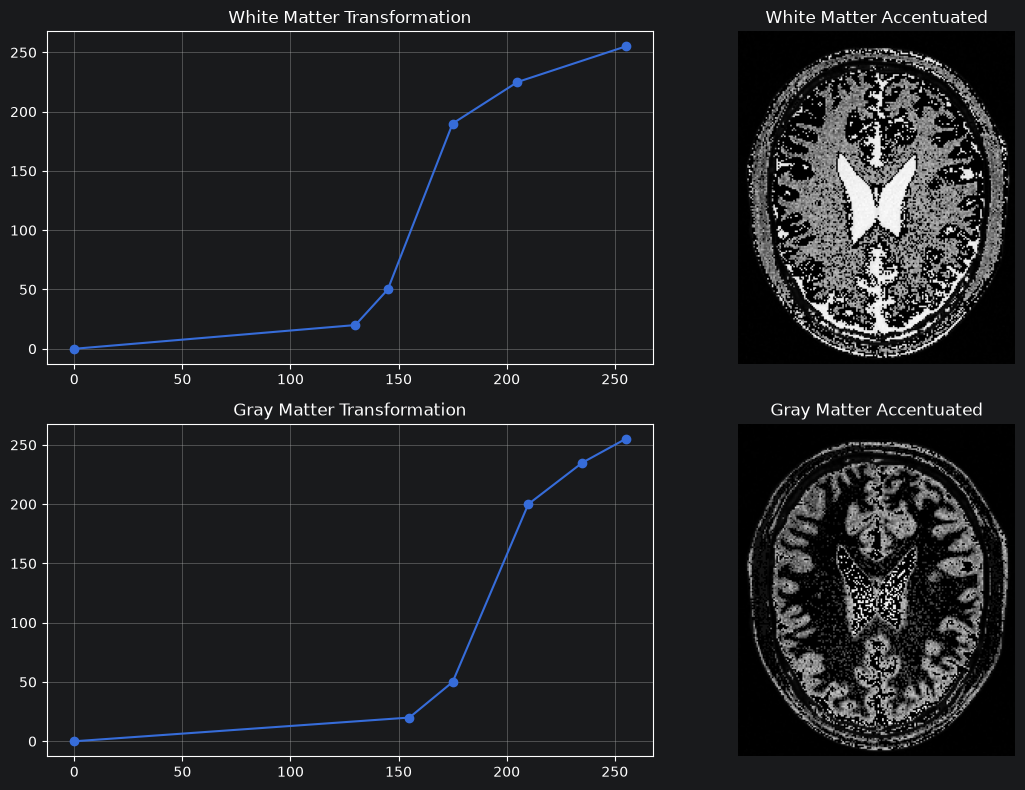

In [14]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(white_bp[:, 0], white_bp[:, 1], marker="o")
plt.title("White Matter Transformation")
plt.grid()

plt.subplot(2, 2, 2)
plt.imshow(white_result, cmap="gray")
plt.title("White Matter Accentuated")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.plot(gray_bp[:, 0], gray_bp[:, 1], marker="o")
plt.title("Gray Matter Transformation")
plt.grid()

plt.subplot(2, 2, 4)
plt.imshow(gray_result, cmap="gray")
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()

Separate linear transformations were used to expand intensity ranges corresponding to white and gray matter. Increased the slope within the corresponding tissue range inorder to increase the contrast between that surrounding regions.

##### Question 3

In [45]:
im3 = cv.imread("Images/Fig3.jpeg")

lab = cv.cvtColor(im3, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

gamma = 0.7

L_norm = L.astype(np.float32) / 255.0
L_gamma = np.power(L_norm, gamma)
L_gamma = np.clip(L_gamma * 255, 0, 255).astype(np.uint8)
lab_gamma = cv.merge([L_gamma, a, b])

result_3 = cv.cvtColor(lab_gamma, cv.COLOR_LAB2RGB)
im3_rgb = cv.cvtColor(im3, cv.COLOR_BGR2RGB)

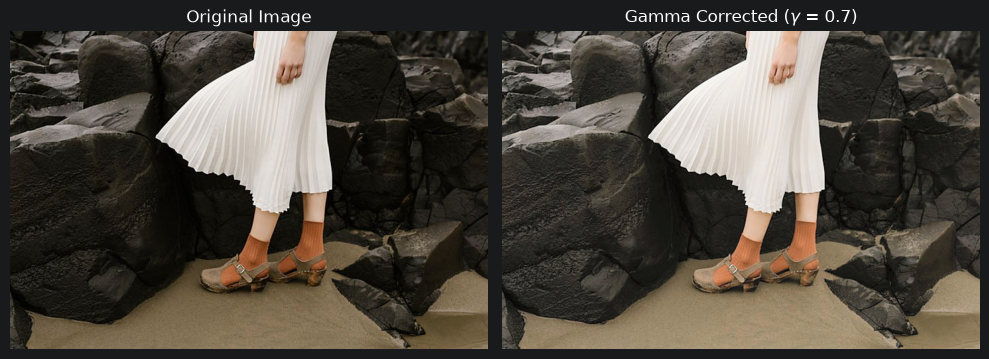

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im3_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_3)
plt.title(f"Gamma Corrected ($\\gamma$ = {gamma})")
plt.axis("off")

plt.tight_layout()
plt.show()

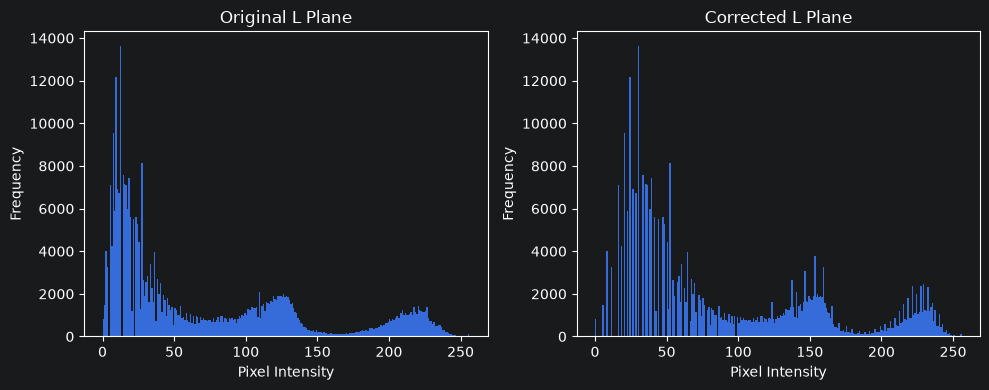

In [44]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(),bins=256,range=(0, 256))
plt.title("Original L Plane")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(L_gamma.ravel(),bins=256,range=(0, 256))
plt.title("Corrected L Plane")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

###### Question 4

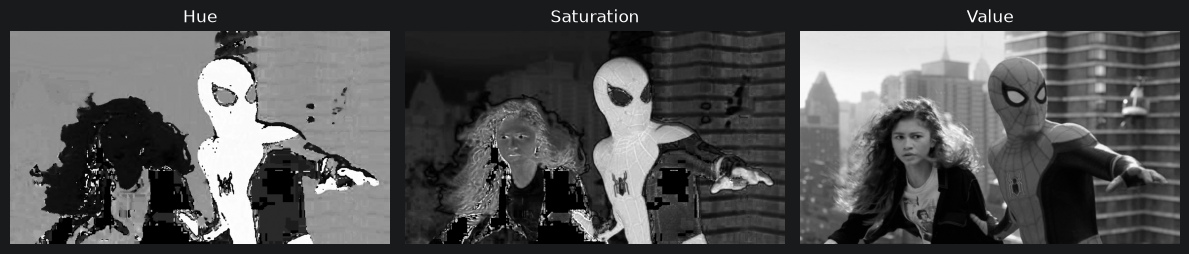

In [18]:
im4 = cv.imread("Images/Fig4.jpeg")
im4_rgb = cv.cvtColor(im4, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(im4, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

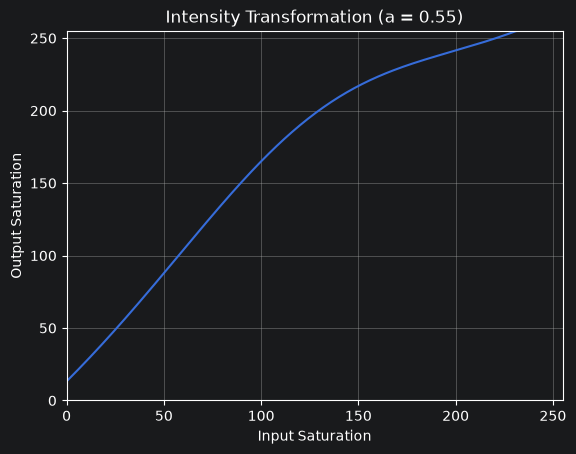

In [19]:
sigma = 70
a_val = 0.55

x = np.arange(256, dtype=np.float32)
f = x + a_val * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
f = np.minimum(f, 255)
plt.plot(x, f)

plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title(f"Intensity Transformation (a = {a_val})")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()
plt.show()

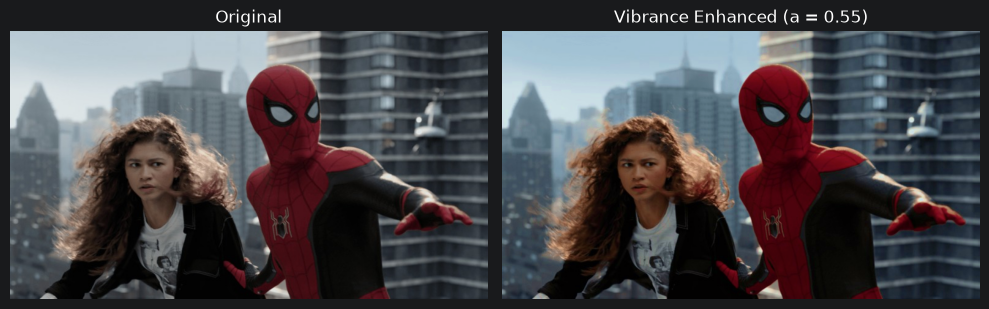

In [20]:
f_uint8 = np.clip(f, 0, 255).astype(np.uint8)
S_enhanced = f_uint8[S]
hsv_enhanced = cv.merge([H, S_enhanced, V])
r4 = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(im4_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(r4)
plt.title(f"Vibrance Enhanced (a = {a_val})")
plt.axis("off")

plt.tight_layout()
plt.show()

a = 0.55

##### Question 05

In [21]:
def histogram_equalization(im):
    hist = np.bincount(im.ravel(), minlength = 256)
    cdf = np.cumsum(hist)
    nz = cdf[cdf > 0]
    cdf_min =  nz[0]
    total_p = im.size

    mapping = ((cdf - cdf_min) / (total_p - cdf_min) * 255)
    mapping = np.clip(mapping, 0, 255).astype(np.uint8)

    equalized = mapping[im]

    return equalized


In [22]:
im5 = cv.imread("Images/shells.tif", cv.IMREAD_GRAYSCALE)
equalized_im = histogram_equalization(im5)

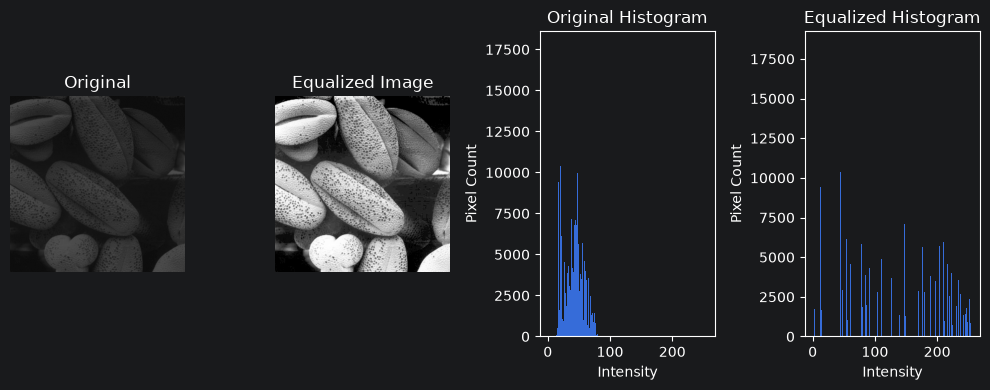

In [23]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 4, 1)
plt.imshow(im5, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(equalized_im, cmap="gray", vmin=0, vmax=255)
plt.title("Equalized Image")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.hist(im5.ravel(),bins=256,range=(0, 256))
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")

plt.subplot(1, 4, 4)
plt.hist(equalized_im.ravel(),bins=256,range=(0, 256))
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")

plt.tight_layout()
plt.show()

##### Question 06

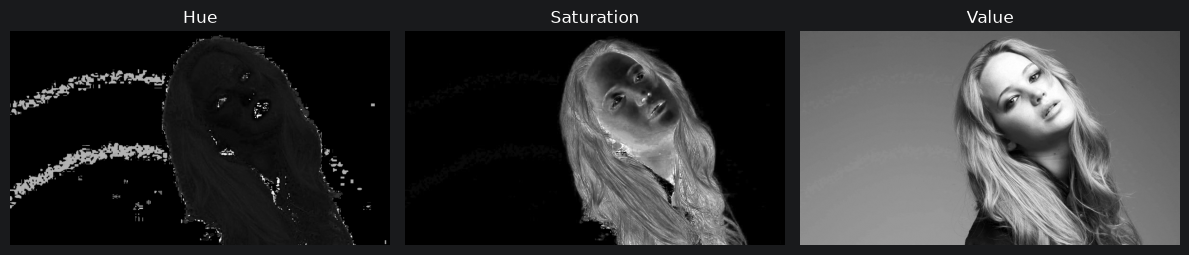

In [25]:
im6 = cv.imread("Images/Fig6.jpeg")
im6_rgb = cv.cvtColor(im6, cv.COLOR_BGR2RGB)

hsv_6 = cv.cvtColor(im6, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv_6)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")
plt.tight_layout()
plt.show()

In [33]:
_, mask6 = cv.threshold(S, 0, 255,cv.THRESH_BINARY + cv.THRESH_OTSU)

foreground = cv.bitwise_and(im6, im6, mask=mask6)
fg_values = V[mask6 > 0]
hist_fg = np.bincount(fg_values, minlength=256)
cdf_fg = np.cumsum(hist_fg)
cdf_min = cdf_fg[cdf_fg > 0][0]
total_fg = fg_values.size

mapping = ((cdf_fg - cdf_min) / (total_fg - cdf_min) * 255)
mapping = np.clip(mapping, 0, 255).astype(np.uint8)
V_equalized = V.copy()
V_equalized[mask6 > 0] = mapping[V[mask6 > 0]]

hsv_equalized = cv.merge([H, S, V_equalized])
equalized_bgr = cv.cvtColor(hsv_equalized, cv.COLOR_HSV2BGR)
equalized_foreground = cv.bitwise_and(equalized_bgr, equalized_bgr, mask=mask6)

background_mask = cv.bitwise_not(mask6)
background = cv.bitwise_and(im6, im6, mask=background_mask)

result6_bgr = cv.add(background, equalized_foreground)

result6_rgb = cv.cvtColor(result6_bgr, cv.COLOR_BGR2RGB)

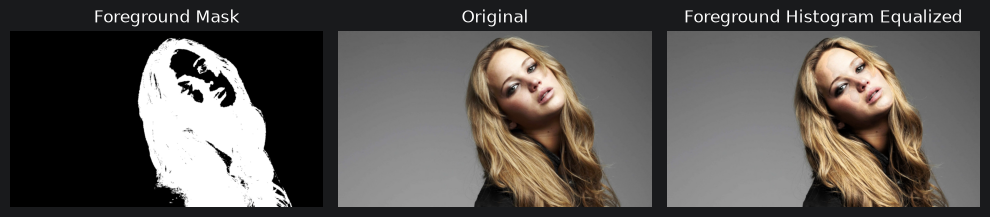

In [31]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(mask6, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(im6_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result6_rgb)
plt.title("Foreground Histogram Equalized")
plt.axis("off")

plt.tight_layout()
plt.show()

##### Question 07

In [37]:
im7 = cv.imread("Images/Fig7.jpeg", cv.IMREAD_GRAYSCALE)
Gx = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

Gy = Gx.T

Part (a)

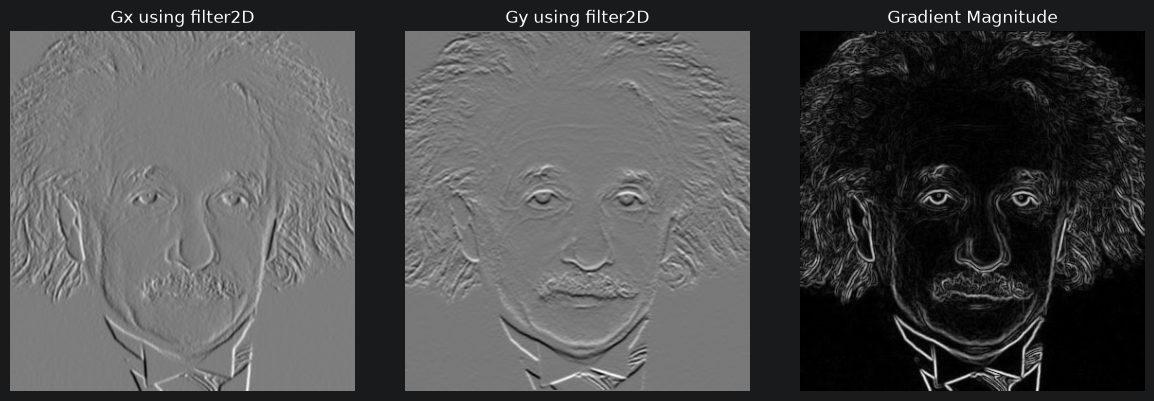

In [39]:
im7_float = im7.astype(np.float32)
gx = cv.filter2D(im7_float, cv.CV_32F, Gx)
gy = cv.filter2D(im7_float, cv.CV_32F, Gy)
mag = np.sqrt(gx ** 2 + gy ** 2)
mag_norm = cv.normalize(mag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(gx, cmap="gray")
plt.title("Gx using filter2D")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gy, cmap="gray")
plt.title("Gy using filter2D")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mag_norm, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

Part (b) - Custom Sobel Filter

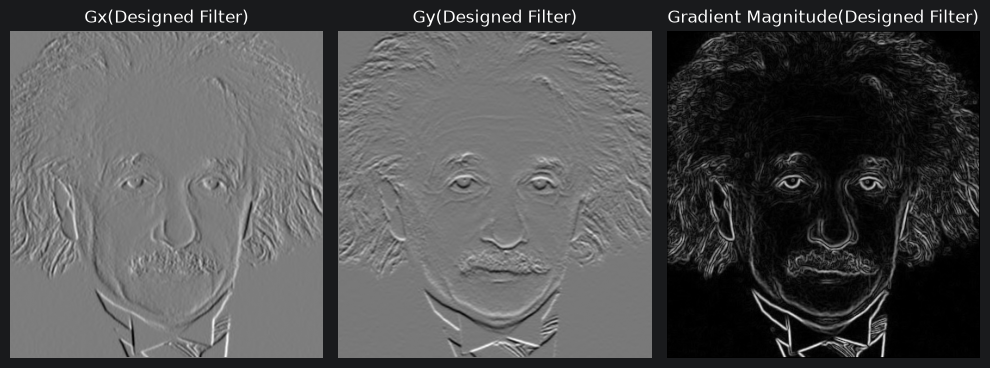

In [42]:
def my_filter(im, filter):
    out = np.zeros_like(im, dtype=np.float32)

    for i in range(1, im.shape[0] - 1):
        for j in range(1, im.shape[1] - 1):
            out[i, j] = np.sum(im[i-1:i+2, j-1:j+2] * filter)
    return out

gx2 = my_filter(im7_float, Gx)
gy2 = my_filter(im7_float, Gy)
mag2 = np.sqrt(gx2**2 + gy2**2)
mag2_norm = cv.normalize(mag2, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(gx2, cmap="gray")
plt.title("Gx(Designed Filter)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gy2, cmap="gray")
plt.title("Gy(Designed Filter)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mag2_norm, cmap="gray")
plt.title("Gradient Magnitude(Designed Filter)")
plt.axis("off")

plt.tight_layout()
plt.show()

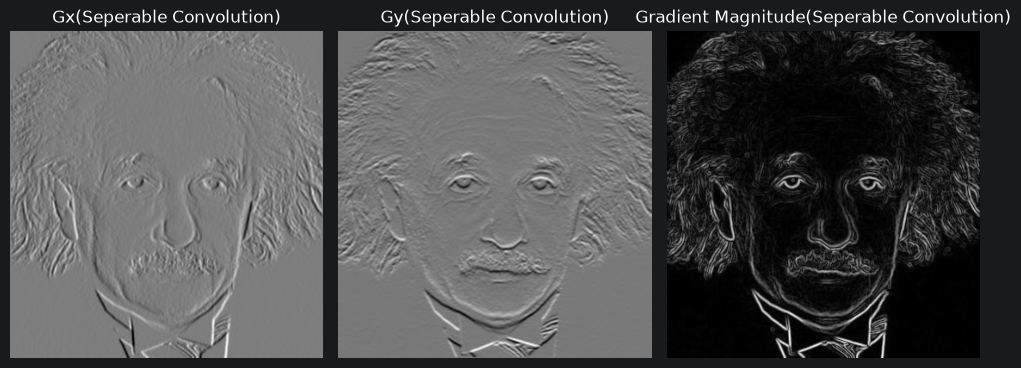

In [43]:
ver = np.array([1, 2, 1], dtype=np.float32)
hr = np.array([1, 0, -1], dtype=np.float32)

gx3 = cv.sepFilter2D(im7_float, cv.CV_32F, hr, ver)
gy3 = cv.sepFilter2D(im7_float, cv.CV_32F, ver, hr)
mag3 = np.sqrt(gx3**2 + gy3**2)
mag3_norm = cv.normalize(mag3, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(gx3, cmap="gray")
plt.title("Gx(Separable Convolution)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gy3, cmap="gray")
plt.title("Gy(Separable Convolution)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mag3_norm, cmap="gray")
plt.title("Gradient Magnitude(Separable Convolution)")
plt.axis("off")

plt.tight_layout()
plt.show()


###### Question 8

In [55]:
def nearest_neighbour(im, s):
    h, w = im.shape[:2]
    new_h = int(h * s)
    new_w = int(w * s)
    out = np.zeros((new_h, new_w, im.shape[2]), dtype=im.dtype)

    for y in range(new_h):
        for x in range(new_w):
            src_x = min(int(x / s), w - 1)
            src_y = min(int(y / s), h - 1)
            out[y, x] = im[src_y, src_x]
    return out

def bilinear_Interpol(im, s):
    h, w = im.shape[:2]
    new_h = int(h * s)
    new_w = int(w * s)
    im_float = im.astype(np.float32)
    out = np.zeros((new_h, new_w, im.shape[2]), dtype=np.uint8)

    for y in range(new_h):
        for x in range(new_w):
            src_y = y / s
            src_x = x / s
            y0 = int(np.floor(src_y))
            x0 = int(np.floor(src_x))
            y1 = min(y0 + 1, h - 1)
            x1 = min(x0 + 1, w - 1)
            dy = src_y - y0
            dx = src_x - x0

            value = ((1-dx)*(1-dy)*im[y0, x0] + dx*(1-dy)*im[y0, x1] + (1-dx)*dy*im[y1, x0] + dx*dy*im[y1, x1])
            out[y, x] = np.clip(value, 0, 255)
    return out

def ssd_norm(ref, test):
    ref = ref.astype(np.float64)
    test = test.astype(np.float64)
    return np.sum((ref - test) ** 2) / np.sum(ref ** 2)

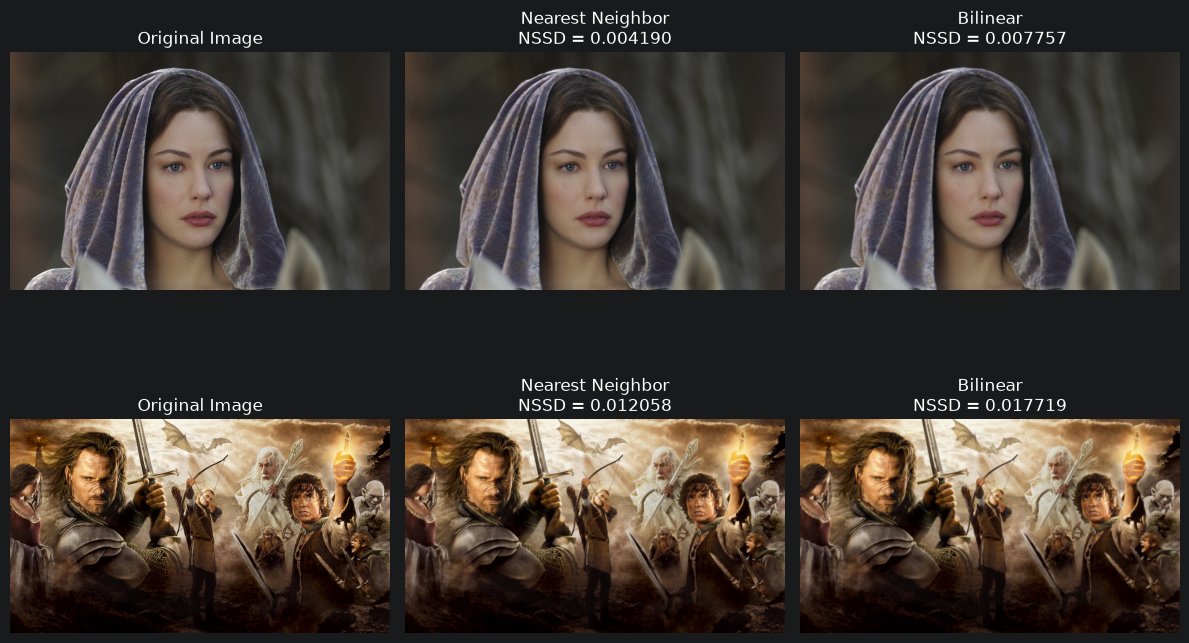

In [56]:
small1 = cv.imread("Images/Fig10_a_small.png")
large1 = cv.imread("Images/Fig10_a.png")
small2 = cv.imread("Images/Fig10_lotr_small.png")
large2 = cv.imread("Images/Fig10_lotr.png")

nn1 = nearest_neighbour(small1, 4)
bi1 = bilinear_Interpol(small1, 4)
ssd_nn1 = ssd_norm(large1, nn1)
ssd_bi1 = ssd_norm(large1, bi1)
nn2 = nearest_neighbour(small2, 4)
bi2 = bilinear_Interpol(small2, 4)
ssd_nn2 = ssd_norm(large2, nn2)
ssd_bi2 = ssd_norm(large2, bi2)

large1_rgb = cv.cvtColor(large1, cv.COLOR_BGR2RGB)
nn1_rgb = cv.cvtColor(nn1, cv.COLOR_BGR2RGB)
bi1_rgb = cv.cvtColor(bi1, cv.COLOR_BGR2RGB)
large2_rgb = cv.cvtColor(large2, cv.COLOR_BGR2RGB)
nn2_rgb = cv.cvtColor(nn2, cv.COLOR_BGR2RGB)
bi2_rgb = cv.cvtColor(bi2, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(large1_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(nn1_rgb)
plt.title(f"Nearest Neighbor\nNSSD = {ssd_nn1:.6f}")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(bi1_rgb)
plt.title(f"Bilinear\nNSSD = {ssd_bi1:.6f}")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(large2_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(nn2_rgb)
plt.title(f"Nearest Neighbor\nNSSD = {ssd_nn2:.6f}")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(bi2_rgb)
plt.title(f"Bilinear\nNSSD = {ssd_bi2:.6f}")
plt.axis("off")

plt.tight_layout()
plt.show()

Question 9

In [ ]:
im9 = cv.imread("Images/Fig8_Flower.jpeg")
im9_rgb = cv.cvtColor(im9, cv.COLOR_BGR2RGB)

h, w = im9.shape[:2]
mask = np.zeros((h, w), np.uint8)

bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)